# Component Property Database — Milestone 4

Every thermodynamic calculation in this library starts with the same question: *what do we know about these compounds?* Critical properties, Antoine coefficients, binary interaction parameters — all of it has to come from somewhere, and the numbers you pick change the answer. This notebook is a guided tour of the SQLite **component property database** that ships with the `vle` package: how it is structured, what has been seeded from the research paper, and how to extend it.

## Context from the research paper

The database is seeded from three tables in [Chapter IV — Validation](../docs/en/research-paper/chapter-4-validation.md) of the thesis. Each table gives us one category of parameters we will need throughout later milestones.

**Pure-component critical properties** come from Chapter IV §4.1, which reports four multicomponent critical-point mixtures and implicitly fixes the `Tc`, `Pc`, `ω` of every pure component that appears in any of them:

> *"Peng and Robinson reported results for critical point calculations of different mixtures. Table 4.1 contains the global compositions of the systems studied [...]."* — [§4.1](../docs/en/research-paper/chapter-4-validation.md#41-critical-point-calculations)

**Activity-model binary parameters** come from Chapter IV §4.3, which gives the van Laar parameters for methanol/water at 298 K:

> *"Using the van Laar model (whose parameters are shown in Table 4.5) for the description of the liquid phase and the ideal gas model for the vapor phase [...]."* — [§4.3 / Table 4.5](../docs/en/research-paper/chapter-4-validation.md#43-bubble-point-pressure)

**Experimental VLE data** for kij regression comes from Chapter IV §4.7 Table 4.11 — 14 P-x-y points for CO₂/n-butane at 357.57 K, of which we seed the 10 used by Da Silva & Báez:

> *"Table 4.11 presents the pressure versus composition data at constant temperature used for solving the stated problem [...]."* — [§4.7 / Table 4.11](../docs/en/research-paper/chapter-4-validation.md#47-binary-interaction-parameter-calculation)

Every value in the seeded database is traceable back to one of these tables or to DIPPR via the `thermo` library.

## What was built in Milestone 4

Milestone 4 adds four pieces that together make the thermodynamic parameters a *queryable resource* rather than a scatter of constants in code:

1. **SQL schema** ([`data/schema.sql`](../data/schema.sql)) — four    tables: `components`, `kij_params`, `activity_params`,    `experimental_vle`, with foreign-key constraints and lookup    indexes. All numeric columns are stored in the canonical units    defined in `CLAUDE.md` (K, kPa absolute, cm³/mol, kJ/(kmol·K), g/mol).
2. **Python package** (`vle.db`) — `connection`, `models` (dataclasses),    `queries` (CRUD), and `seed` (static SQL files + optional `thermo`    library for ~70 k additional compounds).
3. **CLI** (`vle-db` / `python -m vle.cli.main`) — `init`, `seed`,    `validate`, `show`, `list`, `export` subcommands.
4. **Chapter IV seed** ([`data/seed_chapter4.sql`](../data/seed_chapter4.sql)) —    15 compounds, the van Laar methanol/water pair, the PR kij for    CO₂/n-butane, and the 10 experimental VLE points used in Table 4.11.

Everything in this notebook is a thin veneer over that package. If the cells below run, the whole pipeline is healthy.

## Setup

The cell below imports the `vle.db` functions we will use, creates the database from schema if it does not exist yet, and seeds the Chapter IV data. It is **idempotent** — running it a second time is a no-op.

In [1]:
from pathlib import Path

from vle.db.connection import get_db_path, init_db
from vle.db.queries import (
    get_activity_params,
    get_component,
    get_experimental_vle,
    get_kij,
    list_components,
    search_components,
    set_kij,
)
from vle.db.seed import seed_chapter4

db_path = get_db_path()
if not db_path.exists():
    init_db()
    print(f'Created empty database at {db_path}')

count = seed_chapter4()
print(f'Database path: {db_path}')
print(f'Components in database: {count}')

Database path: /Users/migueljackson/Programming/claude/vle/data/components.db
Components in database: 15


## Worked example

We will walk through the four kinds of question the database answers, each one tied back to a Chapter IV table.

### 1. *What compounds do we have?*

In [2]:
comps = list_components()
print(f'{len(comps)} components in the database:\n')
print(f'{"name":<22s} {"formula":<10s} {"Tc (K)":>10s} {"Pc (kPa)":>10s} {"ω":>8s}')
print('-' * 64)
for c in comps:
    print(f'{c.name:<22s} {c.formula or "":<10s} {c.tc:>10.2f} {c.pc:>10.2f} {c.w:>8.4f}')

15 components in the database:

name                   formula        Tc (K)   Pc (kPa)        ω
----------------------------------------------------------------
2-propanol             C3H8O          508.30    4764.00   0.6650
benzene                C6H6           562.02    4907.28   0.2110
carbon dioxide         CO2            304.13    7377.30   0.2239
cyclohexane            C6H12          553.60    4080.50   0.2096
ethane                 C2H6           305.32    4872.20   0.0995
hydrogen sulfide       H2S            373.10    9000.00   0.1005
methane                CH4            190.56    4599.20   0.0114
methanol               CH4O           513.38    8215.85   0.5625
methylcyclohexane      C7H14          572.20    3470.00   0.2340
n-butane               C4H10          425.12    3796.00   0.2010
n-heptane              C7H16          540.20    2735.73   0.3490
n-hexane               C6H14          507.82    3044.10   0.3000
n-pentane              C5H12          469.70    3367.50   

### 2. *Is this compound in the database?*

`search_components` does a case-insensitive partial match over name, formula and CAS number — useful when you do not remember the exact canonical name we used.

In [3]:
for hit in search_components('butane'):
    print(hit.summary())

n-butane  (C4H10)  Tc=425.12 K  Pc=3796.00 kPa  w=0.2010


### 3. *What do we know about one compound?*

`get_component` returns a fully typed `ComponentRecord` dataclass. Here we pull CO₂ — one of the two compounds in the §4.7 kij regression.

In [4]:
co2 = get_component('carbon dioxide')
print(f'Name:        {co2.name}')
print(f'Formula:     {co2.formula}')
print(f'CAS:         {co2.cas_number}')
print(f'MW (g/mol):  {co2.mw}')
print(f'Tc (K):      {co2.tc}')
print(f'Pc (kPa):    {co2.pc}')
print(f'ω:           {co2.w}')
print(f'Source:      {co2.source}')

Name:        carbon dioxide
Formula:     CO2
CAS:         124-38-9
MW (g/mol):  44.0095
Tc (K):      304.1282
Pc (kPa):    7377.3
ω:           0.22394
Source:      thermo/DIPPR


### 4a. *Binary interaction parameter — Table 4.12*

Chapter IV §4.7 reports a regressed PR kij of **0.1357** for CO₂/n-butane at 357.57 K. The value is seeded into `kij_params`.

In [5]:
rec = get_kij('carbon dioxide', 'n-butane', eos_model='PR', temperature=357.57)
print(f'{rec.comp1_name} / {rec.comp2_name}  (EOS: {rec.eos_model}, T = {rec.temperature} K)')
print(f'kij = {rec.kij}   source: {rec.source}')

carbon dioxide / n-butane  (EOS: PR, T = 357.57 K)
kij = 0.1357   source: dasilva1989_table412


### 4b. *Activity-model parameters — Table 4.5*

The van Laar parameters for methanol/water at 298 K (Λ₁₂ = 0.5853, Λ₂₁ = 0.3458) are seeded into `activity_params`. Later milestones will pass them straight into the activity-coefficient module.

In [6]:
vl = get_activity_params('methanol', 'water', model='van_laar', temperature=298.0)
print(f'{vl.comp1_name} / {vl.comp2_name} — {vl.model} at {vl.temperature} K')
print(f'A12 = {vl.a12}')
print(f'A21 = {vl.a21}')
print(f'source: {vl.source}')

methanol / water — van_laar at 298.0 K
A12 = 0.5853
A21 = 0.3458
source: orbey_sandler_ref21


### 4c. *Experimental VLE data — Table 4.11*

The ten P-x-y points we use for the §4.7 kij regression are stored in `experimental_vle`. A P-x-y plot is the usual first sanity check.

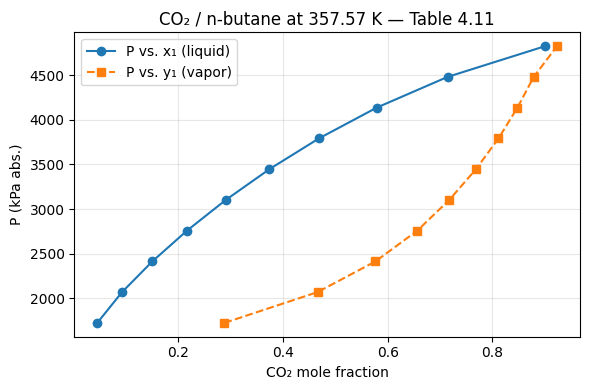

In [7]:
import matplotlib.pyplot as plt

pts = get_experimental_vle('CO2/n-butane')
x1 = [p.x1 for p in pts]
y1 = [p.y1 for p in pts]
P  = [p.pressure for p in pts]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x1, P, 'o-', label='P vs. x₁ (liquid)')
ax.plot(y1, P, 's--', label='P vs. y₁ (vapor)')
ax.set_xlabel('CO₂ mole fraction')
ax.set_ylabel('P (kPa abs.)')
ax.set_title('CO₂ / n-butane at 357.57 K — Table 4.11')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Your turn — exercises

Two short exercises to check you can read and write the database. Template cells with `# TODO:` markers are below; the solutions are in the collapsed block at the end of the notebook.

### Exercise 1 — Reduced temperature at the boiling point

Pull `Tc` for each of the four compounds in the **Chapter IV §4.2 adiabatic flash** — benzene, cyclohexane, methylcyclohexane, n-hexane — and compute the reduced temperature $T_r = T / T_c$ at the flash outlet temperature $T = 394.263$ K (the answer from Table 4.4). Print a small table sorted by $T_r$ ascending.

**Expected**: all four $T_r$ values should fall between roughly 0.69 and 0.78 — a sanity check that the flash is well below any critical point.

In [8]:
# TODO: for each of the four compounds, look it up with get_component()
# TODO: compute Tr = 394.263 / comp.tc
# TODO: print the compound name and Tr, sorted ascending by Tr

T_flash = 394.263  # K, from Table 4.4

compounds = ["benzene", "cyclohexane", "methylcyclohexane", "n-hexane"]

# your code here


### Exercise 2 — Seed a fictitious kij and read it back

Use `set_kij` to insert an RKS kij for methanol/water of `0.042` at 298 K (purely illustrative — do not commit this value to the real database), then use `get_kij` to read it back and assert the round-trip is exact.

Notice that you can call `set_kij('water', 'methanol', ...)` *or* `set_kij('methanol', 'water', ...)` and the query layer normalizes — verify that reading back with the opposite order also works.

In [9]:
# TODO: set_kij("methanol", "water", eos_model="RKS", kij=0.042,
#                temperature=298.0, source="notebook demo")
# TODO: read it back with get_kij and assert the value matches 0.042
# TODO: read it back with the component pair REVERSED and assert it still works

# your code here


### Solutions (expand to see)

<details>
<summary>Click to show Exercise 1 solution</summary>

```python
T_flash = 394.263
rows = []
for name in compounds:
    c = get_component(name)
    rows.append((name, T_flash / c.tc))
rows.sort(key=lambda r: r[1])
for name, tr in rows:
    print(f'{name:<20s} Tr = {tr:.4f}')
```

</details>

<details>
<summary>Click to show Exercise 2 solution</summary>

```python
set_kij('methanol', 'water', eos_model='RKS',
        kij=0.042, temperature=298.0, source='notebook demo')

rec1 = get_kij('methanol', 'water', eos_model='RKS', temperature=298.0)
rec2 = get_kij('water', 'methanol', eos_model='RKS', temperature=298.0)
assert rec1.kij == rec2.kij == 0.042
print('Round-trip OK in both orderings.')
```

</details>

## References

- **Research paper**: [Chapter IV — Validation](../docs/en/research-paper/chapter-4-validation.md), tables 4.1, 4.5, 4.11, 4.12.
- **Parameter reference**: [`docs/en/parameters/parameter_reference.md`](../docs/en/parameters/parameter_reference.md) documents the canonical unit for every column in the schema.
- **Modernization plan**: [`MODERNIZATION_PLAN.md`](../MODERNIZATION_PLAN.md) — Phase 4 describes this database as the input to every later phase.
- **Original Pascal program** (Ref (4)): Da Silva, F. A.; Báez, L., *Ekilib* (1989) — source of the 10 experimental VLE points in Table 4.11 and the kij = 0.1357 regression result in Table 4.12.
- **Orbey & Sandler** (Ref (21)): source of the van Laar methanol/water parameters in Table 4.5.
- **DIPPR 801** (via the `thermo` library): source of critical properties for the 15 seeded compounds.